# BPE + FineWeb-Edu — measurements

What `tokenizer.py` and `fineweb.py` can only be asked about once an artifact exists.
Code-breakable properties live in those files' `__main__`; this is the archive.

Cell 1 is the prelude. Every probe reads from it and from no other probe.


In [1]:
import json
import time
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np

from dataset import BinDataset, load_meta
from fineweb import OUT_DIR
from tokenizer import (
    ENDOFTEXT,
    GPT2_PAT,
    FastBPETokenizer,
    OurBPETokenizer,
    gpt2_ranks,
)

RANKS = gpt2_ranks()
GPT2 = FastBPETokenizer(RANKS, GPT2_PAT, {ENDOFTEXT: 50256})
meta = load_meta(OUT_DIR)


def sample_docs(n_tokens=3_000_000):
    """Text straight back out of the val shard -- no network, and it exercises decode."""
    val = BinDataset("val", OUT_DIR)
    ids = val.tokens(0, min(n_tokens, val.n_tokens)).tolist()
    val.close()
    return [d for d in GPT2.decode(ids).split(ENDOFTEXT) if d]


def truncated(n):
    """GPT-2's table cut to its first n ids. Merges only ever build on lower ranks,
    so a prefix of the table IS the vocab GPT-2 had after n-256 merges."""
    return FastBPETokenizer({b: r for b, r in RANKS.items() if r < n}, GPT2_PAT)


DOCS = sample_docs()
TEXT = "".join(DOCS)
print(f"{len(DOCS)} docs, {len(TEXT) / 1e6:.2f} MB of text decoded from the val shard")

2819 docs, 13.76 MB of text decoded from the val shard


## 1. What does each doubling of the vocab buy?

A near-constant **~0.43 chars/token per doubling** from 512 to 16384, then it tails
(0.38, 0.31). Logarithmic returns with no knee: 8k -> 50k is **6.1x the embedding
rows for 22% fewer tokens**.


vocab    512: 1.988 chars/token    6,920,852 tokens
vocab   1024: 2.453 chars/token    5,608,863 tokens
vocab   2048: 2.874 chars/token    4,786,318 tokens
vocab   4096: 3.311 chars/token    4,154,347 tokens
vocab   8192: 3.745 chars/token    3,672,940 tokens
vocab  16384: 4.130 chars/token    3,331,039 tokens
vocab  32768: 4.441 chars/token    3,097,536 tokens
vocab  50256: 4.590 chars/token    2,997,106 tokens

per doubling: ['0.46', '0.42', '0.44', '0.43', '0.38', '0.31', '0.15']  mean 0.372
8k -> 50k: +22.5% chars/token, 6.1x the rows


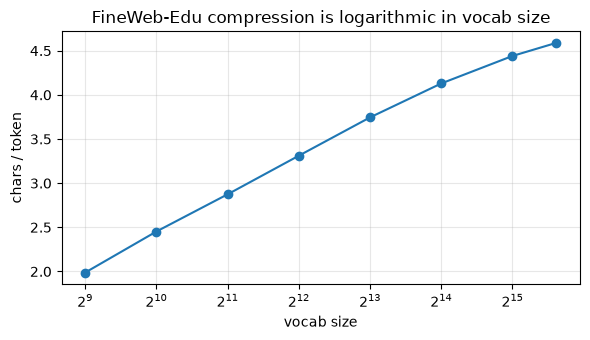

In [2]:
rows = []
for n in (512, 1024, 2048, 4096, 8192, 16384, 32768, 50256):
    ids = truncated(n).encode_ordinary(TEXT)
    rows.append((n, len(TEXT) / len(ids), len(ids)))
    print(f"vocab {n:>6}: {rows[-1][1]:.3f} chars/token   {len(ids):>10,} tokens")

step = [b[1] - a[1] for a, b in zip(rows, rows[1:])]
print(f"\nper doubling: {['%.2f' % s for s in step]}  mean {np.mean(step):.3f}")
print(
    f"8k -> 50k: {rows[-1][1] / rows[4][1] - 1:+.1%} chars/token, "
    f"{50256 / 8192:.1f}x the rows"
)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.semilogx([r[0] for r in rows], [r[1] for r in rows], "o-", base=2)
ax.set_xlabel("vocab size")
ax.set_ylabel("chars / token")
ax.set_title("FineWeb-Edu compression is logarithmic in vocab size")
ax.grid(alpha=0.3)
plt.tight_layout()

## 2. What the merges learn, and in what order

Early merges are letter pairs; late ones are whole words carrying their leading space.
That leading space is the pre-tokenizer's doing — ` the` is one token, `the` after a
quote is another.


In [3]:
ours = OurBPETokenizer.from_mergeable_ranks(RANKS, GPT2_PAT)
by_rank = sorted(ours.merges.items(), key=lambda kv: kv[1])
for label, sl in [
    ("first 12", by_rank[:12]),
    ("ranks 5000-5006", by_rank[4744:4751]),
    ("last 6", by_rank[-6:]),
]:
    print(label)
    for (a, b), idx in sl:
        print(
            f"  {idx:>5}  {ours.vocab[a]!r:>12} + {ours.vocab[b]!r:<12} -> {ours.vocab[idx]!r}"
        )

lens = Counter(len(b) for b in RANKS)
print("\ntoken length (bytes):", dict(sorted(lens.items())))
lead = sum(1 for b in RANKS if b.startswith(b" "))
print(
    f"tokens starting with a space: {lead:,} of {len(RANKS):,} ({lead / len(RANKS):.0%})"
)

first 12
    256          b' ' + b't'         -> b' t'
    257          b' ' + b'a'         -> b' a'
    258          b'h' + b'e'         -> b'he'
    259          b'i' + b'n'         -> b'in'
    260          b'r' + b'e'         -> b're'
    261          b'o' + b'n'         -> b'on'
    262         b' t' + b'he'        -> b' the'
    263          b'e' + b'r'         -> b'er'
    264          b' ' + b's'         -> b' s'
    265          b'a' + b't'         -> b'at'
    266          b' ' + b'w'         -> b' w'
    267          b' ' + b'o'         -> b' o'
ranks 5000-5006
   5000    b' entire' + b'ly'        -> b' entirely'
   5001     b' purch' + b'ase'       -> b' purchase'
   5002         b' e' + b'lement'    -> b' element'
   5003         b' c' + b'ash'       -> b' cash'
   5004     b' deter' + b'mine'      -> b' determine'
   5005          b'D' + b'e'         -> b'De'
   5006         b' c' + b'ars'       -> b' cars'
last 6
  50250      b' ampl' + b'ification' -> b' amplification'


## 3. Why nobody trains a 50k vocab in pure Python

Cost is `merges x corpus`, and the per-merge cost barely falls as the corpus shrinks.
At ~50 ms per merge on 1 MB, GPT-2's 50000 merges would be **~40 minutes on 1 MB** —
and 1 MB is far too little text for the 50000th merge to mean anything.


In [4]:
slice_ = TEXT[:1_000_000]
for v in (512, 1024, 2048):
    t0 = time.time()
    tk = OurBPETokenizer()
    tk.train(slice_, v)
    dt = time.time() - t0
    print(f"vocab {v:>5}: {dt:>5.1f}s   {dt / (v - 256) * 1000:.0f} ms/merge")
print(f"\nextrapolated to 50000 merges on 1 MB: ~{50000 * 0.05 / 60:.0f} min")

vocab   512:  14.9s   58 ms/merge
vocab  1024:  41.6s   54 ms/merge
vocab  2048:  93.4s   52 ms/merge

extrapolated to 50000 merges on 1 MB: ~42 min


## 4. Ours against tiktoken

Same ids, and that is the point of the backend switch — only the speed differs.


In [5]:
probe = TEXT[:300_000]
t0 = time.time()
a = ours.encode_ordinary(probe)
t_ours = time.time() - t0
t0 = time.time()
b = GPT2.encode_ordinary(probe)
t_fast = time.time() - t0
assert a == b
print(f"ours     {len(a) / t_ours / 1e3:>8.1f}k tok/s")
print(f"tiktoken {len(b) / t_fast / 1e6:>8.2f}M tok/s   ({t_ours / t_fast:.0f}x)")
print(f"ids identical over {len(a):,} tokens")

ours        313.7k tok/s
tiktoken     5.63M tok/s   (18x)
ids identical over 64,962 tokens


## 5. GPT-2's vocab was trained on WebText, not on this

It transfers well to FineWeb-Edu -- both are web text -- and badly to TinyStories,
where a 4096-token corpus-specific BPE beats it outright with **12x fewer rows**.
A vocab is a bet on a distribution.


In [6]:
from paths import DATA_ROOT, TOKENIZER_DIR

ts_text = (DATA_ROOT.parent.parent / "data" / "tinystories_validation.txt").read_text()[
    :2_000_000
]
ts_bpe = OurBPETokenizer.load(TOKENIZER_DIR / "bpe_ts_4096.json")

# same text on both sides, so the only thing varying is the vocab
for name, text in [("FineWeb-Edu", TEXT), ("TinyStories", ts_text)]:
    a = len(text) / len(GPT2.encode_ordinary(text))
    b = len(text) / len(ts_bpe.encode(text))
    print(f"{name:<12} GPT-2 50257: {a:.2f}   TinyStories 4096: {b:.2f} chars/token")


FineWeb-Edu  GPT-2 50257: 4.59   TinyStories 4096: 2.70 chars/token
TinyStories  GPT-2 50257: 3.99   TinyStories 4096: 4.13 chars/token


## 6. The corpus that got built

`fineweb.py --build --tokens 1e9`, streamed from `sample-10BT`.


{
  "vocab_size": 50259,
  "source": "HuggingFaceFW/fineweb-edu",
  "config": "sample-10BT",
  "val": {
    "n_chars": 45880697,
    "n_tokens": 10000241,
    "chars_per_token": 4.587959130184963
  },
  "train": {
    "n_chars": 4546769736,
    "n_tokens": 990217589,
    "chars_per_token": 4.591687510410401
  }
}
train:   990,217,589 tokens  10 shard(s)  1.98 GB
  val:    10,000,241 tokens   1 shard(s)  0.02 GB

2819 docs: median 593 tokens, mean 1063, p95 3251, max 26697
docs longer than block_size=1024: 27%


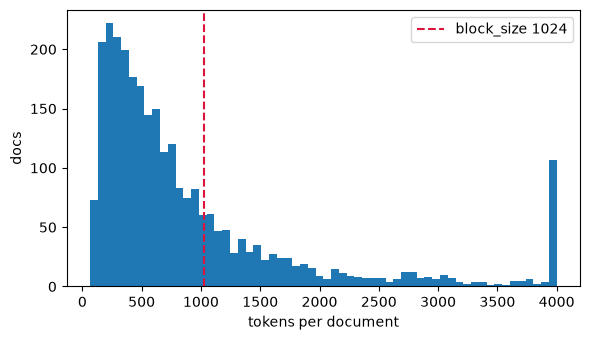

In [7]:
print(json.dumps(meta, indent=2))
for split in ("train", "val"):
    ds = BinDataset(split, OUT_DIR)
    gb = sum(p.stat().st_size for p in ds.paths) / 1e9
    print(
        f"{split:>5}: {ds.n_tokens:>13,} tokens  {len(ds.paths):>2} shard(s)  {gb:.2f} GB"
    )
    ds.close()

doc_lens = [len(GPT2.encode_ordinary(d)) for d in DOCS]
print(
    f"\n{len(doc_lens)} docs: median {int(np.median(doc_lens))} tokens, "
    f"mean {np.mean(doc_lens):.0f}, p95 {int(np.percentile(doc_lens, 95))}, max {max(doc_lens)}"
)
print(f"docs longer than block_size=1024: {np.mean(np.array(doc_lens) > 1024):.0%}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(np.clip(doc_lens, 0, 4000), bins=60)
ax.axvline(1024, color="crimson", ls="--", label="block_size 1024")
ax.set_xlabel("tokens per document")
ax.set_ylabel("docs")
ax.legend()
plt.tight_layout()

## 7. What a 50k vocab costs a small model

The embedding is `vocab_size x n_embed`, tied with `lm_head`, so it is paid once in
parameters -- but the output projection pays it again in FLOPs at every position.
Matmul FLOPs only; attention is excluded, which flatters the head slightly at long
context. This is the number that decides whether GPT-2's vocab is proportionate.


In [8]:
def report(n_layer, n_embed, V=50259, block=1024):
    emb = V * n_embed + block * n_embed
    body = n_layer * 12 * n_embed**2
    tot = emb + body
    head_flops = 2 * V * n_embed
    body_flops = 2 * body
    print(
        f"{n_layer:>2}L/{n_embed:<4} {tot / 1e6:>7.1f}M params   "
        f"embedding {emb / tot:>5.1%}   lm_head {head_flops / (head_flops + body_flops):>5.1%} of fwd matmul FLOPs"
    )


for n_layer, n_embed in [(4, 192), (8, 512), (12, 768), (24, 1024)]:
    report(n_layer, n_embed)
print("\nsame shapes at vocab 8192:")
for n_layer, n_embed in [(4, 192), (8, 512), (12, 768), (24, 1024)]:
    report(n_layer, n_embed, V=8192)

 4L/192     11.6M params   embedding 84.8%   lm_head 84.5% of fwd matmul FLOPs
 8L/512     51.4M params   embedding 51.1%   lm_head 50.6% of fwd matmul FLOPs
12L/768    124.3M params   embedding 31.7%   lm_head 31.2% of fwd matmul FLOPs
24L/1024   354.5M params   embedding 14.8%   lm_head 14.6% of fwd matmul FLOPs

same shapes at vocab 8192:
 4L/192      3.5M params   embedding 50.0%   lm_head 47.1% of fwd matmul FLOPs
 8L/512     29.9M params   embedding 15.8%   lm_head 14.3% of fwd matmul FLOPs
12L/768     92.0M params   embedding  7.7%   lm_head  6.9% of fwd matmul FLOPs
24L/1024   311.4M params   embedding  3.0%   lm_head  2.7% of fwd matmul FLOPs
